i_star: 76006.24978500954, n_star: 63405.947295114645, i_star_co: 338488.92382473906
s_co: 3.856053150748482, s_cm: 1.0594932497775593, interface_E_mo: 245.0101288584406, interface_E_cm: 63.37229739339865


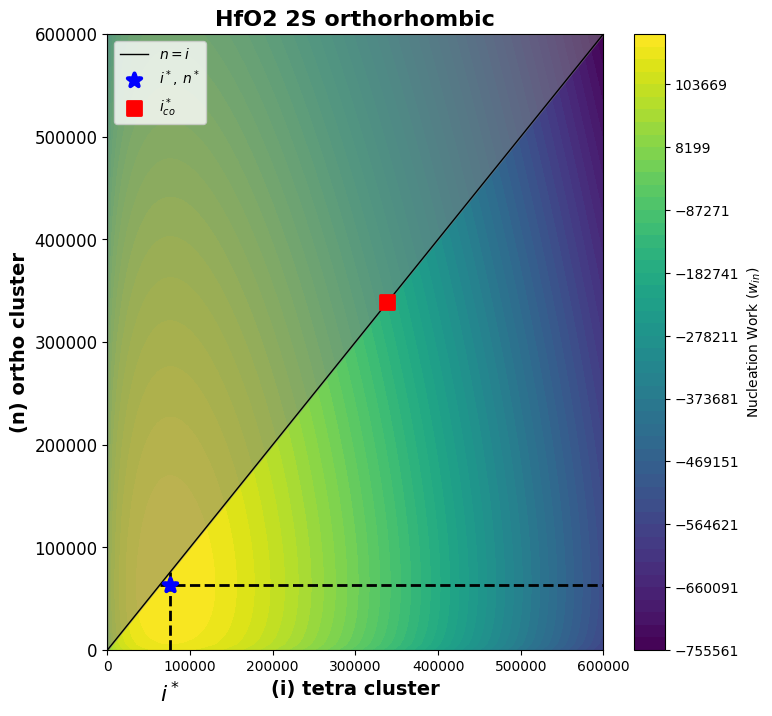

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.transforms import ScaledTranslation

k_B = 8.617e-5  # Boltzmann constant in eV/K
T = 300         # Temperature in Kelvin

volume_c, volume_m, volume_o = 1080.206, 538.507, 1850.971
# Example chemical potentials (eV; 실제 값으로 대체)
chemical_potential_o = -10.01735988
chemical_potential_m = -10.11704271
chemical_potential_c = -10.14443167

# Calculate chemical potential differences
delta_chemical_co = chemical_potential_o - chemical_potential_c
delta_chemical_mo = chemical_potential_o - chemical_potential_m
delta_chemical_cm = chemical_potential_m - chemical_potential_c

# Define i and n value ranges
i_values = np.linspace(1, 600000, 100)
n_values = np.linspace(1, 600000, 100)

s_co = delta_chemical_co / (k_B * T)
interface_E_co = (36*np.pi)**(1/3) * volume_c**(2/3) * 0.418 * 0.06242/(k_B * T)
s_mo = delta_chemical_mo / (k_B * T)
interface_E_mo = (36*np.pi)**(1/3) * volume_m**(2/3) * 0.317 * 0.06242/(k_B * T)
s_cm = delta_chemical_cm / (k_B * T)
interface_E_cm = (36*np.pi)**(1/3) * volume_o**(2/3) * 0.036 * 0.06242/(k_B * T)

# Calculate special points
i_star = (2 * interface_E_mo / (3 * s_mo)) ** 3 
n_star = (2 * interface_E_cm / (3 * s_cm)) ** 3 
i_star_co = (2 * interface_E_co / (3 * s_co)) ** 3 

# 1) 2D 격자 생성 (i, n)
I, N = np.meshgrid(i_values, n_values, indexing='xy')

# 2) 벡터화된 방식으로 nucleation work (w_in) 계산
w_in = (
    -s_mo * I
    + interface_E_mo * (I) ** (2/3)
    - s_cm * N
    + interface_E_cm * (N) ** (2/3)
)

w_star = (((4*interface_E_mo)**3)/((27*s_mo)**2)) + (((4*interface_E_cm)**3)/((27*s_cm)**2))

# 그래프 그리기
plt.figure(figsize=(8, 8))

# 채워진 컨투어: levels 개수를 줄여 색 변화 단위가 크게 나타나도록 함
num_levels = 50  # 색 변화 단계 개수를 줄이면 경계(색이 바뀌는 지점)가 명확해짐
levels = np.linspace(np.min(w_in), np.max(w_in), num_levels)
# colormap을 'plasma'로 변경
cf = plt.contourf(i_values, n_values, w_in, cmap='viridis', levels=levels)
plt.colorbar(cf, label='Nucleation Work ($w_{in}$)')

# ---------------------------
# 1. i < n 영역에 overlay (즉, n > i 영역) 추가
plt.fill_between(i_values, i_values, n_values[-1], color='gray', alpha=0.5)

# ---------------------------
# n = i 직선 (경계선) 추가
plt.plot(i_values, i_values, color='black', linestyle='-', linewidth=1, label='$n = i$')

# ---------------------------
# 특수점 강조
plt.scatter(i_star, n_star, color='blue', marker='*', s=100, linewidths=3, zorder=10, label='$i^*,\, n^*$')
plt.scatter(i_star_co, i_star_co, color='red', marker='s', s=100, linewidths=2, zorder=10, label='$i_{co}^*$')

# ---------------------------
# 점선: i*와 n*에 대한 점선 (조건: i ≥ n 영역에서만 그리기)
# 범례에 나타나지 않도록 label 인자 제거
# 수직 점선: x = i_star, y는 [최소 n값, i_star]
plt.plot([i_star, i_star], [n_values[0], i_star], color='black', linestyle='--', linewidth=2, zorder=9)
# 수평 점선: y = n_star, x는 [n_star, 최대 i값]
plt.plot([n_star, i_values[-1]], [n_star, n_star], color='black', linestyle='--', linewidth=2, zorder=9)

# ---------------------------
# xticks 생성 (특수 tick은 여기서 제외)
all_xticks = list(plt.xticks()[0])
# 특수 tick (i_star, i_star_co)는 따로 표시할 예정하므로 여기서 제거
regular_xticks = [tick for tick in all_xticks if not (np.isclose(tick, i_star) or np.isclose(tick, i_star_co))]
plt.xticks(regular_xticks, [f'{int(x)}' for x in regular_xticks])

# ytick은 그대로 사용
all_yticks = list(plt.yticks()[0])
plt.yticks(all_yticks, [f'{int(y)}' for y in all_yticks])
ax = plt.gca()
for label in ax.get_yticklabels():
    label.set_fontsize(12)

# ---------------------------
# x축 특별 tick (i_star, i_star_co)를 별도의 텍스트로 추가 (높이를 낮춰서)
# x축의 텍스트는 ax.get_xaxis_transform()를 사용하면 좌표 (x, 0)에서 배치됨.
# 여기서 y 좌표를 -0.05 (axes 좌표, 즉 x축 아래쪽)로 지정하여 일반 tick label보다 아래쪽에 위치하도록 함.
ax.text(i_star, -0.05, r'$i^*$', transform=ax.get_xaxis_transform(),
        ha='center', va='top', fontsize=16)


# ---------------------------
# 확인용 출력
print(f"i_star: {i_star}, n_star: {n_star}, i_star_co: {i_star_co}")

# 축 범위 조정
plt.xlim(0, max(max(i_values), i_star, i_star_co) + 10)
plt.ylim(0, max(max(n_values), n_star, i_star_co) + 10)

plt.xlabel('(i) tetra cluster', fontsize=14, fontweight='bold')
plt.ylabel('(n) ortho cluster', fontsize=14, fontweight='bold')
plt.title('HfO2 2S orthorhombic', fontsize=16, fontweight='bold')
plt.legend()

#plt.show()

print(f"s_co: {s_mo}, s_cm: {s_cm}, interface_E_mo: {interface_E_mo}, interface_E_cm: {interface_E_cm}")

#plt.savefig("./test_image", dpi=300, transparent=True)

i_star: 76006.24978500954, n_star: 63405.947295114645, i_star_co: 338488.92382473906
s_mo: 3.856053150748482, s_cm: 1.0594932497775593, interface_E_mo: 245.0101288584406, interface_E_cm: 63.37229739339865


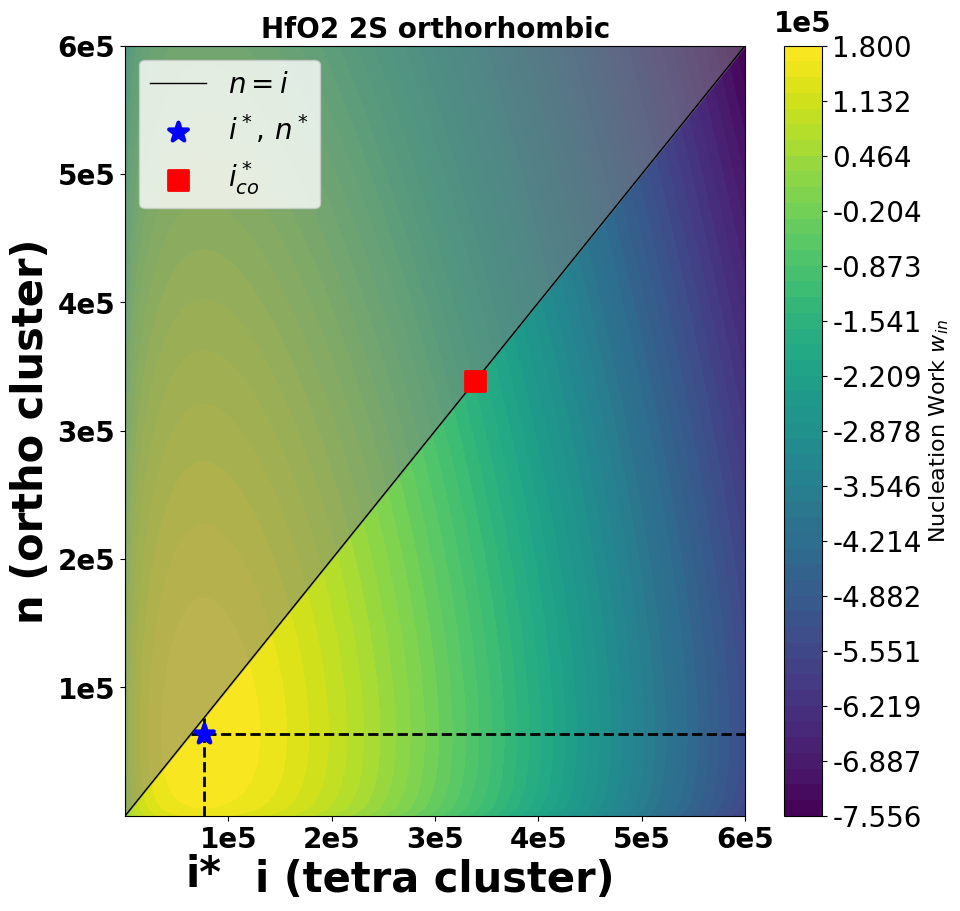

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# ---------------------------
# 1) 기본 상수, 변수 설정
# ---------------------------
k_B = 8.617e-5  # Boltzmann constant in eV/K
T = 300         # Temperature in Kelvin

volume_c, volume_m, volume_o = 1080.206, 538.507, 1850.971
chemical_potential_o = -10.01735988
chemical_potential_m = -10.11704271
chemical_potential_c = -10.14443167

# 화학 퍼텐셜 차이
delta_chemical_co = chemical_potential_o - chemical_potential_c
delta_chemical_mo = chemical_potential_o - chemical_potential_m
delta_chemical_cm = chemical_potential_m - chemical_potential_c

# i, n 값 범위 (1 ~ 600000)
i_values = np.linspace(1, 600000, 100)
n_values = np.linspace(1, 600000, 100)

# ---------------------------
# 2) 에너지·특수점 계산 (원래 좌표계)
# ---------------------------
s_co = delta_chemical_co / (k_B * T)
interface_E_co = (36*np.pi)**(1/3) * volume_c**(2/3) * 0.418 * 0.06242/(k_B * T)

s_mo = delta_chemical_mo / (k_B * T)
interface_E_mo = (36*np.pi)**(1/3) * volume_m**(2/3) * 0.317 * 0.06242/(k_B * T)

s_cm = delta_chemical_cm / (k_B * T)
interface_E_cm = (36*np.pi)**(1/3) * volume_o**(2/3) * 0.036 * 0.06242/(k_B * T)

# 특수점 (i*, n*, i*_co)
i_star = (2 * interface_E_mo / (3 * s_mo)) ** 3
n_star = (2 * interface_E_cm / (3 * s_cm)) ** 3
i_star_co = (2 * interface_E_co / (3 * s_co)) ** 3

# ---------------------------
# 3) w_in 계산 (원래 좌표계로)
# ---------------------------
I, N = np.meshgrid(i_values, n_values, indexing='xy')
w_in = (
    -s_mo * I
    + interface_E_mo * (I)**(2/3)
    - s_cm * N
    + interface_E_cm * (N)**(2/3)
)

w_star = (((4*interface_E_mo)**3)/((27*s_mo)**2)) + (((4*interface_E_cm)**3)/((27*s_cm)**2))

# ---------------------------
# 4) 플롯 준비: w_in을 1e6으로 스케일링
# ---------------------------
w_in_scaled = w_in / 1e5  # 컬러바를 보기 좋게 1e6으로 나눈 값

plt.figure(figsize=(10, 10))

# 등고선 레벨 설정 (스케일된 w_in 사용)
num_levels = 50
levels = np.linspace(np.min(w_in_scaled), np.max(w_in_scaled), num_levels)

# 컨투어 플롯: Z에 스케일된 w_in 사용
cf = plt.contourf(i_values, n_values, w_in_scaled, cmap='viridis', levels=levels)

# ---------------------------
# 5) 컬러바 생성 및 맞춤
# ---------------------------
cbar = plt.colorbar(cf)

# (선택) 컬러바 왼쪽(세로) 라벨: 실제 물리량 표기를 간단히 남길 수도 있음
cbar.set_label('Nucleation Work $w_{in}$', fontsize=16)

# 컬러바 눈금 위치(자동 or 수동 지정 가능).  
# 여기서는 자동 눈금 중 7개 정도로 예시:
num_ticks = 15
tick_vals = np.linspace(np.min(w_in_scaled), np.max(w_in_scaled), num_ticks)

cbar.set_ticks(tick_vals)
# 소수점으로 표현 (예: 0.715, 0.816, ...)
cbar.set_ticklabels([f'{val:.3f}' for val in tick_vals], fontsize =20)

# 컬러바 맨 위에 "1e6" 표기
# pad: 컬러바와의 간격, fontsize: 글자 크기
cbar.ax.set_title("1e5", pad=10, fontsize=20, fontweight='bold')

# ---------------------------
# 6) 메인 플롯 (i, n)
# ---------------------------
# n > i 영역을 회색으로 표시
plt.fill_between(i_values, i_values, n_values[-1], color='gray', alpha=0.5)

# n = i 직선
plt.plot(i_values, i_values, color='black', linestyle='-', linewidth=1, label='$n = i$')

# 특수점 표시
plt.scatter(i_star, n_star, color='blue', marker='*', s=200, linewidths=3, zorder=10, label='$i^*,\, n^*$')
plt.scatter(i_star_co, i_star_co, color='red', marker='s', s=200, linewidths=2, zorder=10, label='$i_{co}^*$')

# i* 수직 점선, n* 수평 점선
plt.plot([i_star, i_star], [0, i_star], color='black', linestyle='--', linewidth=2, zorder=9)
plt.plot([n_star, i_values[-1]], [n_star, n_star], color='black', linestyle='--', linewidth=2, zorder=9)

# x, y 축 라벨 및 폰트 설정
plt.xlabel(r'i (tetra cluster)', fontsize=30, fontweight='bold')
plt.ylabel(r'n (ortho cluster)', fontsize=30, fontweight='bold')
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')

# 제목, 범례
plt.title('HfO2 2S orthorhombic', fontsize=20, fontweight='bold')
plt.legend(fontsize=20)

# 축 범위
plt.xlim(0, i_values[-1])
plt.ylim(0, n_values[-1])

# x축 특수점 라벨 (i_star 위치)
ax = plt.gca()
ax.text(i_star, -0.05, r'i*', transform=ax.get_xaxis_transform(),
        ha='center', va='top', fontsize=30, fontweight='bold')

# (선택) x, y 축 눈금 1e5 단위 표시
xticks = np.arange(1e5, 600001, 1e5)
ax.set_xticks(xticks)
ax.set_xticklabels([f'{int(tick/1e5)}e5' for tick in xticks], fontsize=20, fontweight='bold')

yticks = np.arange(1e5, 600001, 1e5)
ax.set_yticks(yticks)
ax.set_yticklabels([f'{int(tick/1e5)}e5' for tick in yticks], fontsize=20, fontweight='bold')

# 확인용 출력
print(f"i_star: {i_star}, n_star: {n_star}, i_star_co: {i_star_co}")
print(f"s_mo: {s_mo}, s_cm: {s_cm}, interface_E_mo: {interface_E_mo}, interface_E_cm: {interface_E_cm}")

#plt.show()
plt.savefig("./test_image", dpi=300, transparent=True)

In [ ]:
volume_c, volume_m, volume_o = 1080.206, 538.507, 1850.971

# Chemical potentials
chemical_potential_o = -10.01735988
chemical_potential_m = -10.11704271
chemical_potential_c = -10.17260479

i_star: 145161.24430993898, n_star: 1637807.119012786, i_star_co: 220859.95332768172
s_mo: 3.856053150748482, s_cm: 2.149320335770362, interface_E_mo: 303.9843074253178, interface_E_cm: 380.0260127083704


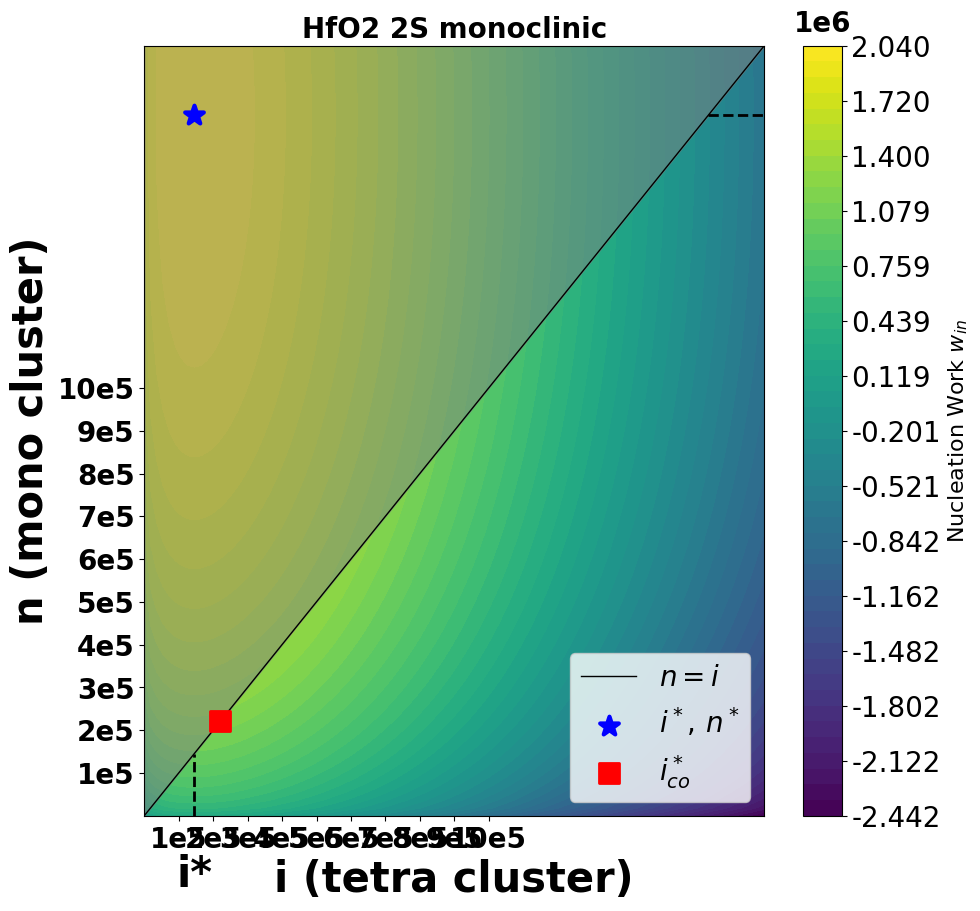

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# ---------------------------
# 1) 기본 상수, 변수 설정
# ---------------------------
k_B = 8.617e-5  # Boltzmann constant in eV/K
T = 300         # Temperature in Kelvin

volume_c, volume_m, volume_o = 1080.206, 538.507, 1850.971

# Chemical potentials
chemical_potential_o = -10.01735988
chemical_potential_m = -10.11704271
chemical_potential_c = -10.17260479

# 화학 퍼텐셜 차이
delta_chemical_co = chemical_potential_o - chemical_potential_c
delta_chemical_mo = chemical_potential_o - chemical_potential_m
delta_chemical_cm = chemical_potential_m - chemical_potential_c

# i, n 값 범위 (1 ~ 600000)
i_values = np.linspace(1, 1800000, 100)
n_values = np.linspace(1, 1800000, 100)

# ---------------------------
# 2) 에너지·특수점 계산 (원래 좌표계)
# ---------------------------
s_co = delta_chemical_co / (k_B * T)
interface_E_co = 6 * volume_c**(2/3) * 0.357 * 0.06242 / (k_B * T)
s_mo = delta_chemical_mo / (k_B * T)
interface_E_mo = 6 * volume_m**(2/3) * 0.317 * 0.06242 / (k_B * T)
s_cm = delta_chemical_cm / (k_B * T)
interface_E_cm = 6 * volume_o**(2/3) * 0.174 * 0.06242 / (k_B * T)
# 특수점 (i*, n*, i*_co)
i_star = (2 * interface_E_mo / (3 * s_mo)) ** 3
n_star = (2 * interface_E_cm / (3 * s_cm)) ** 3
i_star_co = (2 * interface_E_co / (3 * s_co)) ** 3

# ---------------------------
# 3) w_in 계산 (원래 좌표계로)
# ---------------------------
I, N = np.meshgrid(i_values, n_values, indexing='xy')
w_in = (
    -s_mo * I
    + interface_E_mo * (I)**(2/3)
    - s_cm * N
    + interface_E_cm * (N)**(2/3)
)

w_star = (((4*interface_E_mo)**3)/((27*s_mo)**2)) + (((4*interface_E_cm)**3)/((27*s_cm)**2))

# ---------------------------
# 4) 플롯 준비: w_in을 1e6으로 스케일링
# ---------------------------
w_in_scaled = w_in / 1e6  # 컬러바를 보기 좋게 1e6으로 나눈 값

plt.figure(figsize=(10, 10))

# 등고선 레벨 설정 (스케일된 w_in 사용)
num_levels = 50
levels = np.linspace(np.min(w_in_scaled), np.max(w_in_scaled), num_levels)

# 컨투어 플롯: Z에 스케일된 w_in 사용
cf = plt.contourf(i_values, n_values, w_in_scaled, cmap='viridis', levels=levels)

# ---------------------------
# 5) 컬러바 생성 및 맞춤
# ---------------------------
cbar = plt.colorbar(cf)

# (선택) 컬러바 왼쪽(세로) 라벨: 실제 물리량 표기를 간단히 남길 수도 있음
cbar.set_label('Nucleation Work $w_{in}$', fontsize=16)

# 컬러바 눈금 위치(자동 or 수동 지정 가능).  
# 여기서는 자동 눈금 중 7개 정도로 예시:
num_ticks = 15
tick_vals = np.linspace(np.min(w_in_scaled), np.max(w_in_scaled), num_ticks)

cbar.set_ticks(tick_vals)
# 소수점으로 표현 (예: 0.715, 0.816, ...)
cbar.set_ticklabels([f'{val:.3f}' for val in tick_vals], fontsize =20)

# 컬러바 맨 위에 "1e6" 표기
# pad: 컬러바와의 간격, fontsize: 글자 크기
cbar.ax.set_title("1e6", pad=10, fontsize=20, fontweight='bold')

# ---------------------------
# 6) 메인 플롯 (i, n)
# ---------------------------
# n > i 영역을 회색으로 표시
plt.fill_between(i_values, i_values, n_values[-1], color='gray', alpha=0.5)

# n = i 직선
plt.plot(i_values, i_values, color='black', linestyle='-', linewidth=1, label='$n = i$')

# 특수점 표시
plt.scatter(i_star, n_star, color='blue', marker='*', s=200, linewidths=3, zorder=10, label='$i^*,\, n^*$')
plt.scatter(i_star_co, i_star_co, color='red', marker='s', s=200, linewidths=2, zorder=10, label='$i_{co}^*$')

# i* 수직 점선, n* 수평 점선
plt.plot([i_star, i_star], [0, i_star], color='black', linestyle='--', linewidth=2, zorder=9)
plt.plot([n_star, i_values[-1]], [n_star, n_star], color='black', linestyle='--', linewidth=2, zorder=9)

# x, y 축 라벨 및 폰트 설정
plt.xlabel(r'i (tetra cluster)', fontsize=30, fontweight='bold')
plt.ylabel(r'n (mono cluster)', fontsize=30, fontweight='bold')
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')

# 제목, 범례
plt.title('HfO2 2S monoclinic', fontsize=20, fontweight='bold')
plt.legend(fontsize=20)

# 축 범위
plt.xlim(0, i_values[-1])
plt.ylim(0, n_values[-1])

# x축 특수점 라벨 (i_star 위치)
ax = plt.gca()
ax.text(i_star, -0.05, r'i*', transform=ax.get_xaxis_transform(),
        ha='center', va='top', fontsize=30, fontweight='bold')

# (선택) x, y 축 눈금 1e5 단위 표시
xticks = np.arange(1e5, 1000001, 1e5)
ax.set_xticks(xticks)
ax.set_xticklabels([f'{int(tick/1e5)}e5' for tick in xticks], fontsize=20, fontweight='bold')

yticks = np.arange(1e5, 1000001, 1e5)
ax.set_yticks(yticks)
ax.set_yticklabels([f'{int(tick/1e5)}e5' for tick in yticks], fontsize=20, fontweight='bold')

# 확인용 출력
print(f"i_star: {i_star}, n_star: {n_star}, i_star_co: {i_star_co}")
print(f"s_mo: {s_mo}, s_cm: {s_cm}, interface_E_mo: {interface_E_mo}, interface_E_cm: {interface_E_cm}")

#plt.show()
plt.savefig("./test_image", dpi=300, transparent=True)

[INFO] 300K 기준 w_in 범위 (스케일 후): -7.556 ~ 1.800
[INFO] 현재 플롯에 사용할 T: 800 K


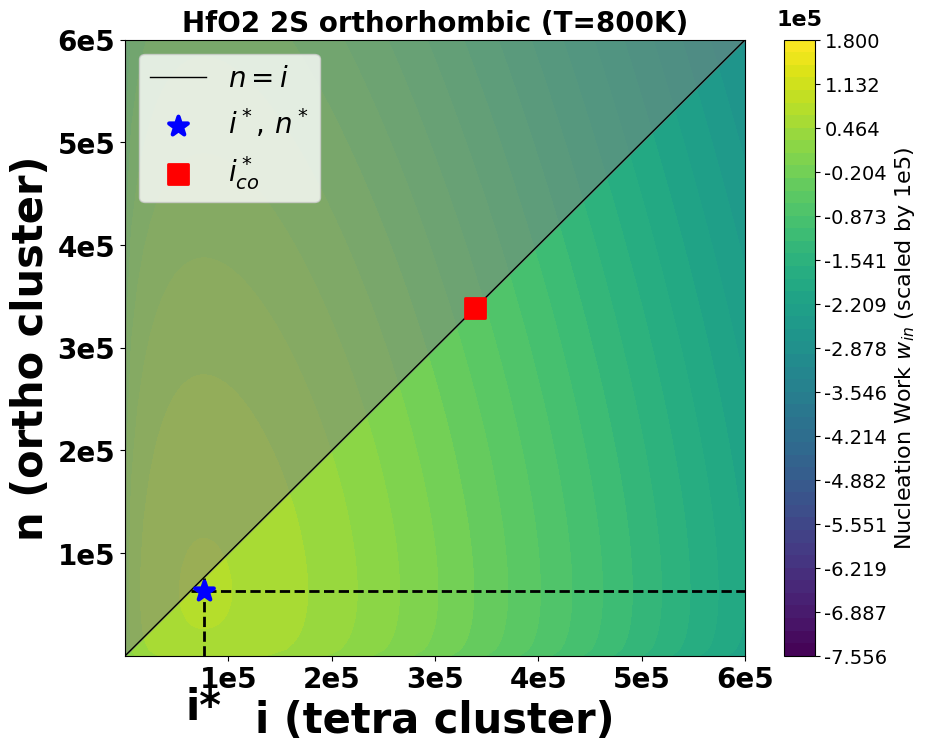

In [63]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# 0) 공통 설정 (상수, 크기 등)
# ---------------------------
k_B = 8.617e-5  # Boltzmann constant in eV/K

volume_c, volume_m, volume_o = 1080.206, 538.507, 1850.971
chemical_potential_o = -10.01735988
chemical_potential_m = -10.11704271
chemical_potential_c = -10.14443167

delta_chemical_co = chemical_potential_o - chemical_potential_c
delta_chemical_mo = chemical_potential_o - chemical_potential_m
delta_chemical_cm = chemical_potential_m - chemical_potential_c

# i, n 범위
i_values = np.linspace(1, 600000, 100)
n_values = np.linspace(1, 600000, 100)

# ---------------------------
# 1) "참조" 온도(T=300K)에서 w_in 범위 미리 계산
# ---------------------------
T_ref = 300  # 고정 기준(참조) 온도
s_co_ref = delta_chemical_co / (k_B * T_ref)
s_mo_ref = delta_chemical_mo / (k_B * T_ref)
s_cm_ref = delta_chemical_cm / (k_B * T_ref)

interface_E_co_ref = (36*np.pi)**(1/3) * volume_c**(2/3) * 0.418 * 0.06242/(k_B * T_ref)
interface_E_mo_ref = (36*np.pi)**(1/3) * volume_m**(2/3) * 0.317 * 0.06242/(k_B * T_ref)
interface_E_cm_ref = (36*np.pi)**(1/3) * volume_o**(2/3) * 0.036 * 0.06242/(k_B * T_ref)

I_ref, N_ref = np.meshgrid(i_values, n_values, indexing='xy')
w_in_ref = (
    -s_mo_ref * I_ref
    + interface_E_mo_ref * (I_ref)**(2/3)
    - s_cm_ref * N_ref
    + interface_E_cm_ref * (N_ref)**(2/3)
)

# 스케일링 (컬러바 단위를 1e5로 표기)
w_in_ref_scaled = w_in_ref / 1e5
fixed_min = np.min(w_in_ref_scaled)
fixed_max = np.max(w_in_ref_scaled)

print(f"[INFO] 300K 기준 w_in 범위 (스케일 후): {fixed_min:.3f} ~ {fixed_max:.3f}")

# ---------------------------
# 2) 실제 플롯에 사용할 온도 T 설정
#    (여기서 T를 300K 외 다른 값으로 바꾸더라도 컬러바는 300K 기준 범위를 사용)
# ---------------------------
T = 800  # 예를 들어 300K (다른 값으로 바꿔도 고정범위를 사용)
print(f"[INFO] 현재 플롯에 사용할 T: {T} K")

s_co = delta_chemical_co / (k_B * T)
s_mo = delta_chemical_mo / (k_B * T)
s_cm = delta_chemical_cm / (k_B * T)

interface_E_co = (36*np.pi)**(1/3) * volume_c**(2/3) * 0.418 * 0.06242/(k_B * T)
interface_E_mo = (36*np.pi)**(1/3) * volume_m**(2/3) * 0.317 * 0.06242/(k_B * T)
interface_E_cm = (36*np.pi)**(1/3) * volume_o**(2/3) * 0.036 * 0.06242/(k_B * T)

I, N = np.meshgrid(i_values, n_values, indexing='xy')
w_in = (
    -s_mo * I
    + interface_E_mo * (I)**(2/3)
    - s_cm * N
    + interface_E_cm * (N)**(2/3)
)

w_in_scaled = w_in / 1e5

# ---------------------------
# 3) 플롯 (고정된 컬러바 범위 사용)
# ---------------------------
plt.figure(figsize=(10, 8))

num_levels = 50
levels = np.linspace(fixed_min, fixed_max, num_levels)  # ★ 고정 범위 사용

cf = plt.contourf(i_values, n_values, w_in_scaled, cmap='viridis', levels=levels)
cbar = plt.colorbar(cf)
cbar.set_label('Nucleation Work $w_{in}$ (scaled by 1e5)', fontsize=16)

# 컬러바 눈금 수동 설정
num_ticks = 15
tick_vals = np.linspace(fixed_min, fixed_max, num_ticks)
cbar.set_ticks(tick_vals)
cbar.set_ticklabels([f'{val:.3f}' for val in tick_vals], fontsize=14)

# 컬러바 맨 위에 "1e5" 단위 표시
cbar.ax.set_title("1e5", pad=10, fontsize=16, fontweight='bold')

# ---------------------------
# 4) 메인 플롯 (i, n) 구성
# ---------------------------
# n > i 영역 회색 표시
plt.fill_between(i_values, i_values, n_values[-1], color='gray', alpha=0.5)
# n = i 직선
plt.plot(i_values, i_values, color='black', linestyle='-', linewidth=1, label='$n = i$')

# 특수점 표시
# i_star, n_star (파란 별)
i_star = (2 * interface_E_mo / (3 * s_mo)) ** 3
n_star = (2 * interface_E_cm / (3 * s_cm)) ** 3
plt.scatter(i_star, n_star, color='blue', marker='*', s=200, linewidths=3, zorder=10, label='$i^*,\, n^*$')

# i_star_co (ico_star; 빨간 사각형)
i_star_co = (2 * interface_E_co / (3 * s_co)) ** 3
plt.scatter(i_star_co, i_star_co, color='red', marker='s', s=200, linewidths=2, zorder=10, label='$i_{co}^*$')

# i* 수직 점선, n* 수평 점선
plt.plot([i_star, i_star], [0, i_star], color='black', linestyle='--', linewidth=2, zorder=9)
plt.plot([n_star, i_values[-1]], [n_star, n_star], color='black', linestyle='--', linewidth=2, zorder=9)

# ---------------------------
# 5) 축, 제목, 범례 설정
# ---------------------------
plt.xlabel('i (tetra cluster)', fontsize=30, fontweight='bold')
plt.ylabel('n (ortho cluster)', fontsize=30, fontweight='bold')
plt.title(f'HfO2 2S orthorhombic (T={T}K)', fontsize=20, fontweight='bold')
plt.legend(fontsize=20)

plt.xlim(0, i_values[-1])
plt.ylim(0, n_values[-1])

# x축 특수점 라벨 (i_star 위치)
ax = plt.gca()
ax.text(i_star, -0.05, 'i*', transform=ax.get_xaxis_transform(),
        ha='center', va='top', fontsize=30, fontweight='bold')

# x, y 축 눈금을 1e5 단위로 표시
xticks = np.arange(1e5, 600001, 1e5)
ax.set_xticks(xticks)
ax.set_xticklabels([f'{int(tick/1e5)}e5' for tick in xticks], fontsize=20, fontweight='bold')

yticks = np.arange(1e5, 600001, 1e5)
ax.set_yticks(yticks)
ax.set_yticklabels([f'{int(tick/1e5)}e5' for tick in yticks], fontsize=20, fontweight='bold')

plt.savefig("test_image.png", dpi=300, transparent=True)
plt.show()


C:\Users\USER\AppData\Local\Temp\ipykernel_18108\2178838250.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, fontsize=30, fontweight='bold')


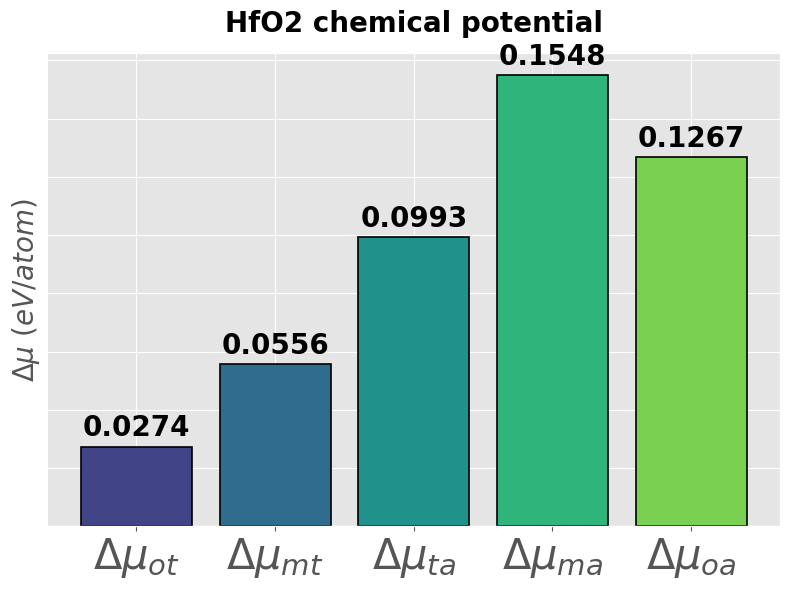

In [103]:
import matplotlib.pyplot as plt
import numpy as np

# ggplot 스타일 사용
plt.style.use('ggplot')

# 데이터 준비
labels = [
    r'$\Delta\mu_{ot}$',
    r'$\Delta\mu_{mt}$',
    r'$\Delta\mu_{ta}$',
    r'$\Delta\mu_{ma}$',
    r'$\Delta\mu_{oa}$'
]
values = [0.02739, 0.0555625, 0.099276235, 0.154838735, 0.126666235]

# 컬러맵에서 각 막대마다 다른 색 추출
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(values)))

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(labels, values, color=colors, edgecolor='black', linewidth=1.2)

# 막대 위에 값 표시
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=20, fontweight='bold')

# y축 라벨 설정 (눈금은 제거할 예정)
ax.set_ylabel(r'$\Delta\mu\ (eV/atom)$', fontsize=20, fontweight='bold')
ax.set_title('HfO2 chemical potential', fontsize=20, pad=15, fontweight='bold')

# x축 레이블 설정
ax.set_xticklabels(labels, fontsize=30, fontweight='bold')

# y축 눈금 및 tick label 제거 (라벨은 그대로 유지)
ax.tick_params(axis='y', which='both', left=False, labelleft=False)
# 필요에 따라 y축의 왼쪽 spine도 제거할 수 있음
ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.savefig("test_image2.png", dpi=300, transparent=True)
plt.show()



C:\Users\USER\AppData\Local\Temp\ipykernel_18108\3662662957.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, fontsize=30, fontweight='bold')


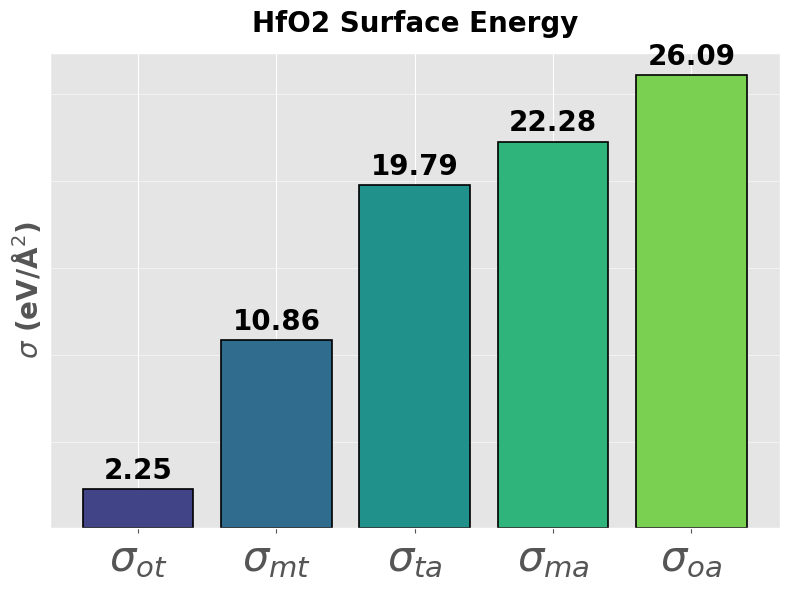

In [104]:
import matplotlib.pyplot as plt
import numpy as np

# ggplot 스타일 사용
plt.style.use('ggplot')

# 데이터 준비 (주어진 순서: to -> tm -> at -> am -> ao)
labels = [
    r'$\sigma_{ot}$',
    r'$\sigma_{mt}$',
    r'$\sigma_{ta}$',
    r'$\sigma_{ma}$',
    r'$\sigma_{oa}$'
]
values = [2.24712, 10.86108, 19.78714, 22.28394, 26.09156]

# 컬러맵에서 막대마다 다른 색을 추출
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(values)))

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(labels, values, color=colors, edgecolor='black', linewidth=1.2)

# 막대 위에 값 표시
ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=20, fontweight='bold')

# 축과 제목 설정
ax.set_ylabel(r'$\sigma$ (eV/Å$^2$)', fontsize=20, fontweight='bold')
ax.set_title('HfO2 Surface Energy', fontsize=20, pad=15, fontweight='bold')

# x축 레이블 설정
ax.set_xticklabels(labels, fontsize=30, fontweight='bold')
ax.tick_params(axis='y', which='both', left=False, labelleft=False)
# y축에만 그리드 표시
ax.grid(axis='y', alpha=0.5)

plt.tight_layout()
plt.savefig("sigma_plot.png", dpi=300, transparent=True)
plt.show()
